In [ ]:
import os

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from experiments.make_basic_rnn_model import utilities

In [ ]:
data = pd.read_csv('res/wz_rnn_gridsearch.csv')
data['real_bit_rate']=data['real_bit_rate'].apply(lambda x: eval(x[6:]) if x[:6]=='tensor' else eval(None))

In [ ]:
data2 = pd.read_csv('res/wz_monolithic.csv')
data2['real_bit_rate']=data2['real_bit_rate'].apply(lambda x: eval(x[6:]) if x[:6]=='tensor' else eval(None))

In [ ]:
temp = np.random.normal(0, np.sqrt(1), 1_000_000, ).astype(np.float32)
y = temp + np.random.normal(0, np.sqrt(0.01), 1_000_000, ).astype(np.float32)
side_info_data = [temp]
side_info_variance, noise_variance = utilities.get_data_var(y, side_info_data)

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(22, 10))
for i, ax in enumerate(axes):
    bound_x_y = utilities.bound_lines(y, side_info_variance, noise_variance, mape_flag=(i==1))
    ax.plot(bound_x_y[0], bound_x_y[1], linewidth=1, label='WZ bound')
    ax.plot(bound_x_y[0], bound_x_y[1]+bound_x_y[2], linewidth=1, linestyle=':', label='Lattice error bound')

    # for mk, br in [('s', 'softcodes_bit_rate'), ('o', 'prior_bit_rate'), ('x','real_bit_rate'),]:
    #     ax.scatter(eval(br), 10 * np.log10(mse if i == 0 else mspe), label=br, s=100, marker=mk)
    ax.scatter(data['real_bit_rate'], 10 * np.log10(data['mse'] if i == 0 else data['mspe']),
               label='real_bit_rate', s=100, marker='x')
    ax.scatter(data2['real_bit_rate'], 10 * np.log10(data2['mse'] if i == 0 else data2['mspe']),
               label='monolithic', s=100, marker='o')

    ax.set_xlabel('Bit Rate (bpp)')
    ax.set_ylabel('Distortion (dB)')
    # ax.grid(True)
    ax.legend()
axes[0].set_title('MSE')
axes[1].set_title('mspe')
plt.show()

In [ ]:
def plot(results, first_name='tau', second_name='lr', t_name='efctv_bit_rate'):
    target_names = ['MAPE% (db)', t_name]
    x_axis = results[f'params_{first_name}']
    y_axis = results[f'params_{second_name}']
    temp = np.log10(results['value']) * 10
    z_axis = [temp, results[f'user_attrs_{target_names[1]}']]

    x_lim = [(a.min()-0.1,a.max()+0.1) for a in (x_axis, y_axis)]
    # x_lim[0] = (10, 10)
    # x_lim[1] = (0, 5)

    # Create 2D heat maps
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, z in enumerate(z_axis):
        ax = axes[i]
        im = ax.hexbin(x_axis, y_axis, C=z, gridsize=30, cmap='viridis', mincnt=1)
        ax.set_xlabel(first_name)
        ax.set_ylabel(second_name)
        ax.set_title(f'Optimization Results Heat Map for {target_names[i]}')
        fig.colorbar(im, ax=ax, label=target_names[i])

    plt.tight_layout()
    plt.show()

    # Create individual parameter plots
    param_names = [first_name, second_name]
    param_data = [x_axis, y_axis]

    for param_idx, (param_name, param_values) in enumerate(zip(param_names, param_data)):
        for i, z in enumerate(z_axis):
            plt.figure(figsize=(15, 4))

            # Sort by parameter values for better visualization
            sorted_indices = np.argsort(param_values)
            sorted_x = param_values.iloc[sorted_indices]
            sorted_y = z.iloc[sorted_indices]


            # Scatter plot of the data points
            plt.scatter(sorted_x, sorted_y, label=param_name, marker='o', alpha=0.6, s=15)

            # Calculate and plot the mean line with std deviation
            bins = np.linspace(sorted_x.min(), sorted_x.max(), 15)
            digitized = np.digitize(sorted_x, bins)
            bin_means = [sorted_y[digitized == j].mean() for j in range(1, len(bins))]
            bin_stds = [sorted_y[digitized == j].std() for j in range(1, len(bins))]
            bin_centers = (bins[:-1] + bins[1:]) / 2

            bin_means = np.array(bin_means)
            bin_stds = np.array(bin_stds)

            plt.plot(bin_centers, bin_means, color='red', linewidth=2, label='Mean Trend')
            plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds,
                             color='red', alpha=0.2, label='Std Dev')

            plt.xlabel(param_name)
            plt.ylabel(target_names[i])
            plt.title(f'{param_name} vs {target_names[i]}')
            plt.grid(True, alpha=0.3)
            plt.xlim(x_lim[param_idx])
            plt.legend()
            plt.show()


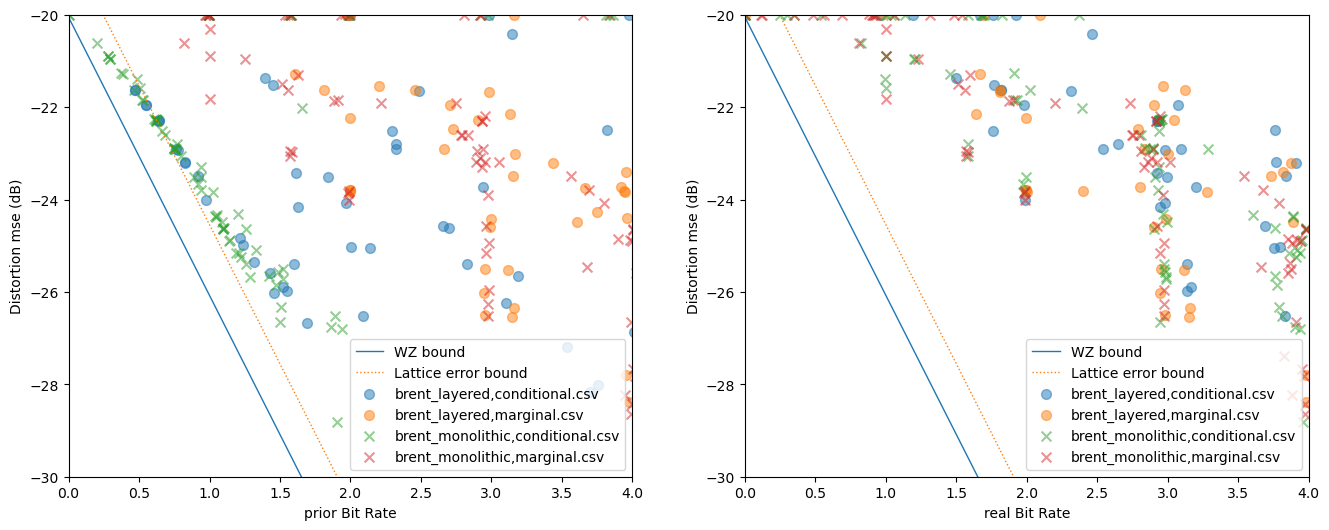

In [21]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from experiments.make_basic_rnn_model import utilities
import os


side_info_data = [np.random.normal(0, np.sqrt(1), 1_000_000, ).astype(np.float32)]
y = side_info_data[0] + np.random.normal(0, np.sqrt(0.01), 1_000_000, ).astype(np.float32)
bound_x_y = utilities.bound_lines(y, *utilities.get_data_var(y, side_info_data))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, ax in enumerate(axes):
    ax.plot(bound_x_y[0], bound_x_y[1], linewidth=1, label='WZ bound')
    ax.plot(bound_x_y[0], bound_x_y[1] + bound_x_y[2], linewidth=1, linestyle=':', label='Lattice error bound')

    data_name = ['prior_bit_rate', 'real_bit_rate'][i]
    temp = iter(['o', 'o', 'x', 'x',])
    for filename in os.listdir('res/'):
        data = pd.read_csv(f'res/{filename}')
        ax.scatter(data[data_name], data['mse'], s=50, alpha=0.5, marker=next(temp), label=filename)
    ax.set_xlabel(f'{data_name.split('_')[0]} Bit Rate')
    ax.set_ylabel('Distortion mse (dB)')
    ax.legend()
    ax.set_xlim(0,4)
    ax.set_ylim(-30,-20)
plt.show()


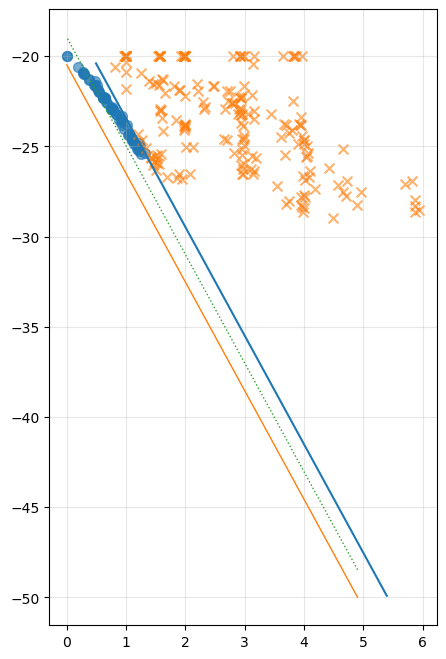

,mse,real_bit_rate,prior_bit_rate,whole_code_size,num_planes,lr,tau,reconst_ld,distance
20,-24.018145,1.988923,0.973325,4,2,0.001,1,100,0.379429
36,-21.633285,1.818655,0.469359,4,2,0.001,1,400,0.273037
37,-21.621939,1.818770,0.471220,4,2,0.001,1,400,0.276731
38,-21.956110,1.982678,0.550280,4,2,0.001,1,400,0.299968
39,-22.295778,2.921162,0.639674,8,3,0.001,1,400,0.332500
...,...,...,...,...,...,...,...,...,...
181,-22.898974,3.288307,0.759758,16,1,0.010,1,1000,0.352126
182,-22.881440,2.893846,0.749216,8,1,0.001,1,400,0.344599
183,-24.609436,3.761147,1.101909,16,1,0.010,1,1000,0.409391
184,-22.878082,2.835345,0.745410,8,1,0.001,1,400,0.341395


In [20]:
def seperate_point_close_to_line(points, points_line, threshold):
    A = points_line[0]
    B = points_line[1]
    AB = B - A
    AP = points - A
    AB_length_squared = np.dot(AB, AB)
    if AB_length_squared == 0:
        return points, np.empty((0, 2)), False
    projection = np.dot(AP, AB) / AB_length_squared
    closest_point_on_line = A + projection[:, np.newaxis] * AB
    distances = np.linalg.norm(points - closest_point_on_line, axis=1)

    close_points = points[distances <= threshold]
    far_points = points[distances > threshold]

    in_region = (distances <= threshold)

    return close_points, far_points, in_region, distances

def get_parallel_lines_at_distance(line_points, distance):
    line_points = np.array(line_points)
    tangents = np.diff(line_points, axis=0)
    normals = np.column_stack([-tangents[:, 1], tangents[:, 0]])
    normal_lengths = np.linalg.norm(normals, axis=1)
    unit_normals = normals / normal_lengths[:, np.newaxis]
    averaged_normals = np.zeros_like(line_points)
    averaged_normals[0] = unit_normals[0]
    for i in range(1, len(line_points) - 1):
        averaged_normals[i] = (unit_normals[i-1] + unit_normals[i]) / 2
        averaged_normals[i] = averaged_normals[i] / np.linalg.norm(averaged_normals[i])
    averaged_normals[-1] = unit_normals[-1]
    upper_line = line_points + distance * averaged_normals
    lower_line = line_points - distance * averaged_normals
    return upper_line, lower_line


data = pd.concat([pd.read_csv(f'res/{fn}') for fn in os.listdir('res/')], ignore_index=True)

dist=0.5
temp = (np.array([data['prior_bit_rate'], data['mse']]).T, np.array(bound_x_y[:2]).T)
close_points, far_points, in_region, point_distances = seperate_point_close_to_line(*temp, dist)
data['distance'] = point_distances
paralel_line = get_parallel_lines_at_distance(temp[1],dist)

temp = np.abs((temp[0].min(axis=0)-temp[1].max(axis=0))).round()
plt.figure(figsize=temp)
plt.plot(*paralel_line[1].T)
plt.plot(bound_x_y[0], bound_x_y[1], linewidth=1)
plt.plot(bound_x_y[0], bound_x_y[1] + bound_x_y[2], linewidth=1, linestyle=':')
plt.scatter(close_points[:, 0], close_points[:, 1], s=50, alpha=0.6, marker='o', label='Close Points')
plt.scatter(far_points[:, 0], far_points[:, 1], s=50, alpha=0.6, marker='x', label='Far Points')
plt.grid(True, alpha=0.3)
plt.show()

data[in_region]